## Imports

In [1]:
import pickle
from itertools import zip_longest

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from brainiak.eventseg.event import EventSegment
from scipy.spatial.distance import cdist
from scipy.stats import wasserstein_distance
from tqdm.notebook import tqdm

from analysis_helpers import Episode, Participant
from analysis_helpers.constants import FIG_DIR

## Functions

In [2]:
def proximal_diag_mask(event_mask):
    diag_mask = np.zeros_like(event_mask)
    rowcol_ixs = np.arange(diag_mask.shape[0])

    for k in range(1, diag_mask.shape[0]):
        kth_diag_ixs = (rowcol_ixs[:-k], rowcol_ixs[k:])
        if not (event_mask[kth_diag_ixs] > 0).any():
            break
        diag_mask[kth_diag_ixs] = True
        
    return diag_mask

In [3]:
def create_event_trajectory(
        trajectory: np.ndarray, 
        eventseg_model: EventSegment
) -> np.ndarray:
    """
    Reduce a timepoints x topics matrix to an events x topics matrix, 
    averaging topic weights over timepoints within each event.
    """
    labels = eventseg_model.segments_[0].argmax(axis=1)
    boundaries = np.flatnonzero(np.diff(labels)) + 1
    return np.vstack([
        chunk.mean(axis=0) for chunk in np.split(trajectory, boundaries)
    ])

## Load data

In [4]:
atlep1 = Episode('atlep1')

participants = Participant.load_all()
avg_participant = Participant('average')

In [5]:
N_EVENTS_RANGE = np.arange(2, 51)
N_SPLIT_MERGE_PROPOSALS = 3

## Find optimal number of events for episodes

In [6]:
pbar = tqdm(total=len(N_EVENTS_RANGE) * 1, leave=False)
for episode in (atlep1,):
    episode_corrmat = np.corrcoef(episode.trajectory)
    wasserstein_dists = []
    max_wd = 0
    
    for n_events in N_EVENTS_RANGE:
        pbar.set_description(f'{episode.name}, K={n_events}')
        hmm = EventSegment(n_events, 
                           split_merge=True, 
                           split_merge_proposals=N_SPLIT_MERGE_PROPOSALS)
        hmm.fit(episode.trajectory)
        
        event_assignments = hmm.segments_[0] == hmm.segments_[0].max(axis=1, keepdims=True)
        event_mask = np.dot(event_assignments, event_assignments.T)
        diag_mask = proximal_diag_mask(event_mask)
        
        within_corrs = episode_corrmat[event_mask * diag_mask]
        across_corrs = episode_corrmat[~event_mask * diag_mask]
        
        wd = wasserstein_distance(within_corrs, across_corrs)
        if wd > max_wd:
            max_wd = wd
            best_eventseg = hmm
        
        wasserstein_dists.append(wd)
        pbar.update()
        
    episode.eventseg_model = best_eventseg
    episode.eventseg_kvals = np.array(wasserstein_dists)
    
pbar.close()

## Plot $K$-optimization curves

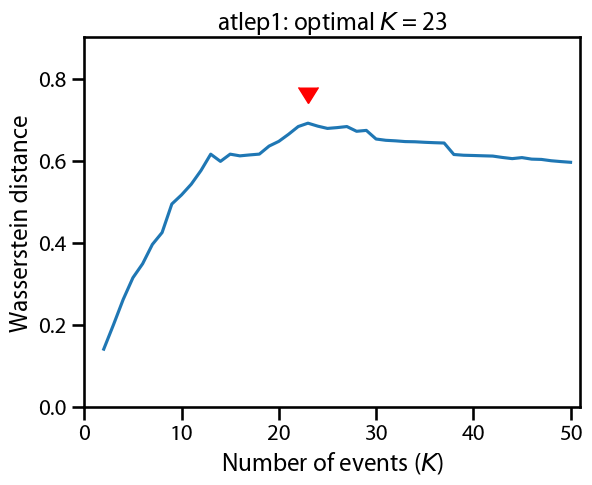

In [7]:
with sns.plotting_context('talk'):
    for episode in (atlep1,):
        best_k = N_EVENTS_RANGE[episode.eventseg_kvals.argmax()]
        ax = sns.lineplot(x=N_EVENTS_RANGE, y=episode.eventseg_kvals)
        ax.plot(best_k, episode.eventseg_kvals.max() + 0.05, c='r', marker=7, markersize=15)
        ax.set_xlim(0, 51)
        ax.set_ylim(0, 0.9)
        ax.set_xlabel('Number of events ($K$)')
        ax.set_ylabel('Wasserstein distance')
        ax.set_title(f'{episode.name}: optimal $K$ = {best_k}')
#         plt.savefig(FIG_DIR.joinpath(f'k-optimization-{episode.name}.pdf'), 
#                     bbox_inches='tight')
        plt.show()

## Segment episode trajectories & save data

In [8]:
# for episode in (atlep1,):
#     episode.events = create_event_trajectory(episode.trajectory, episode.eventseg_model)
    
#     np.save(episode.data_dir.joinpath('events.npy'), episode.events)
#     np.save(episode.data_dir.joinpath('eventseg_kvals.npy'), episode.eventseg_kvals)
#     episode.data_dir.joinpath('eventseg_model.p').write_bytes(
#         pickle.dumps(episode.eventseg_model)
#     )

## Load recall $K$-optimization results from HPC cluster, segment recall trajectories & save
see [code/cluster-scripts/eventseg/](https://github.com/ContextLab/memory-dynamics/tree/master/code/cluster-scripts/eventseg)

In [9]:
for p in participants:
    for rectype in ('atlep1', 'delayed'):
        p.events[rectype] = create_event_trajectory(p.trajectories[rectype], 
                                                    p.eventseg_models[rectype])
        np.save(p.data_dir.joinpath(f'{rectype}_recall_events.npy'), p.events[rectype])

## Plot $K$-optimization curves

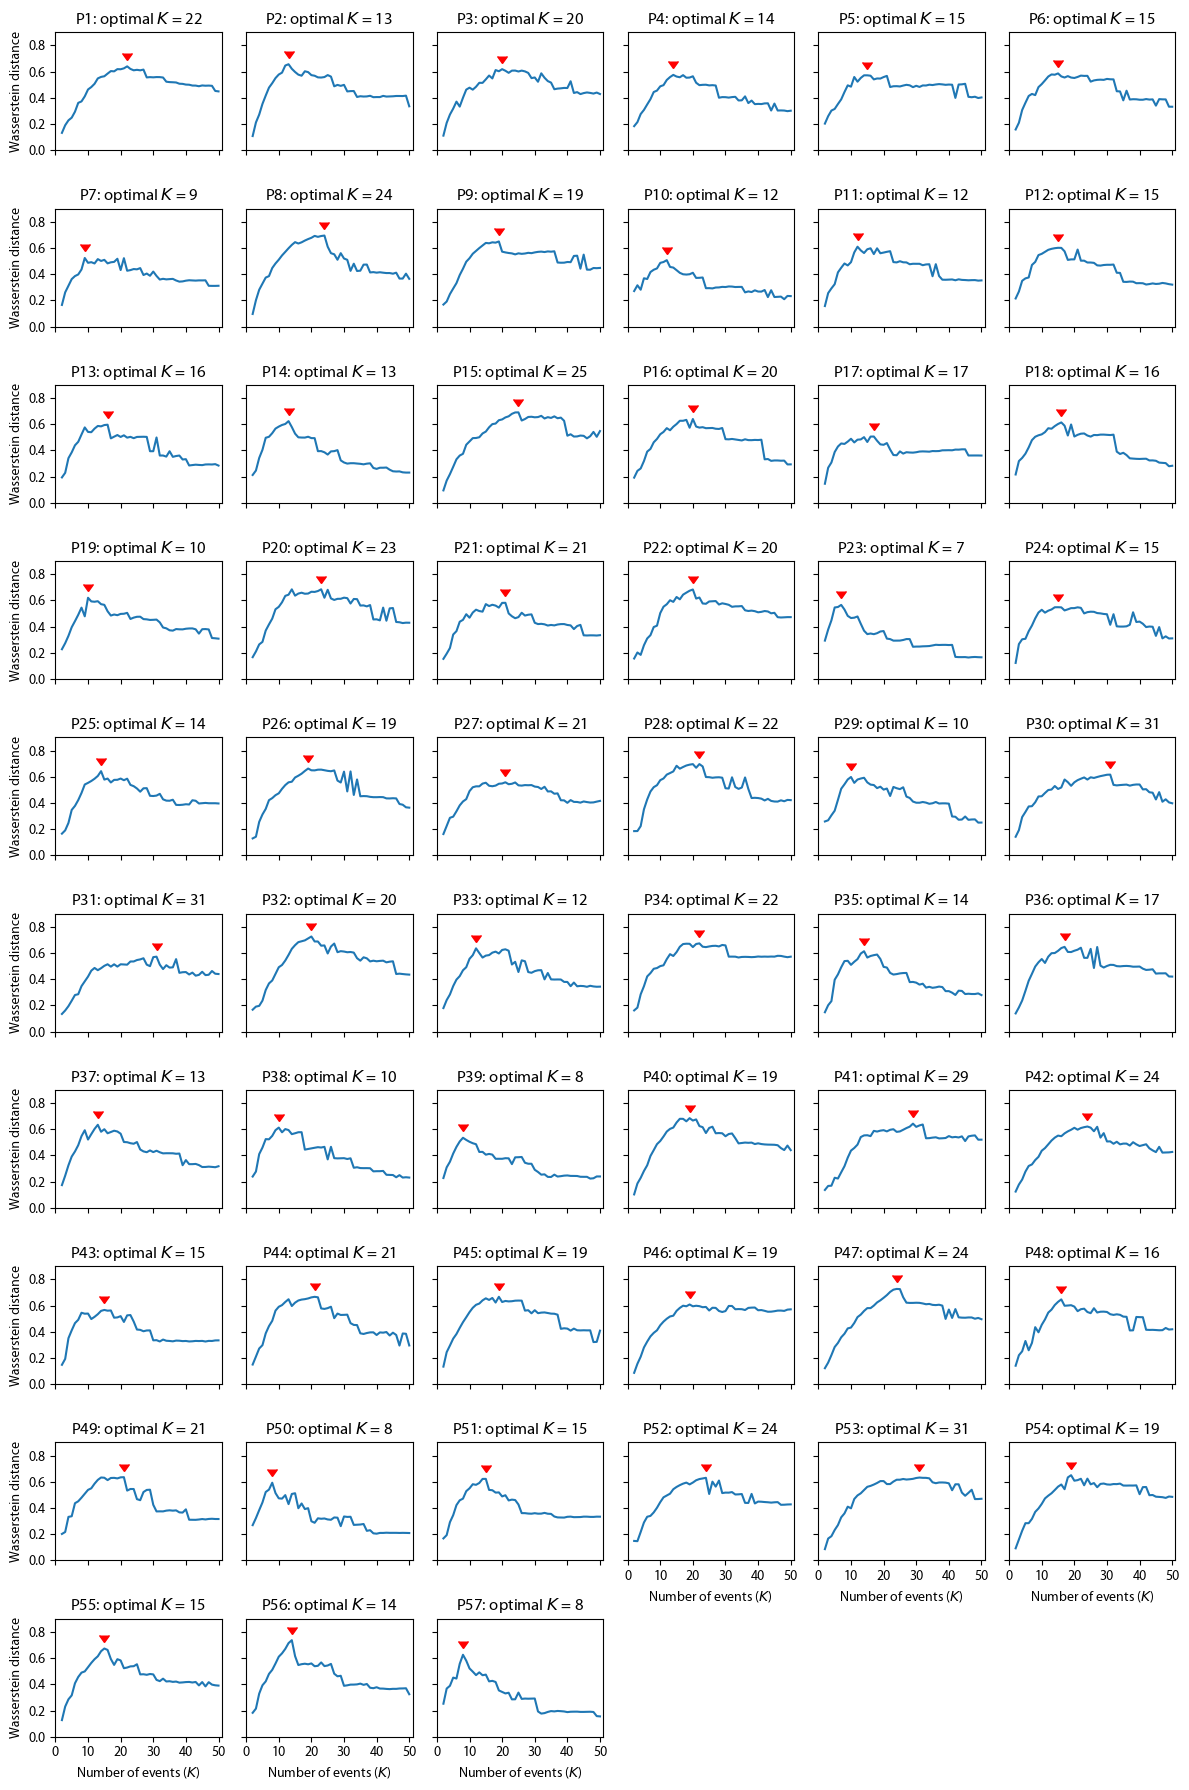

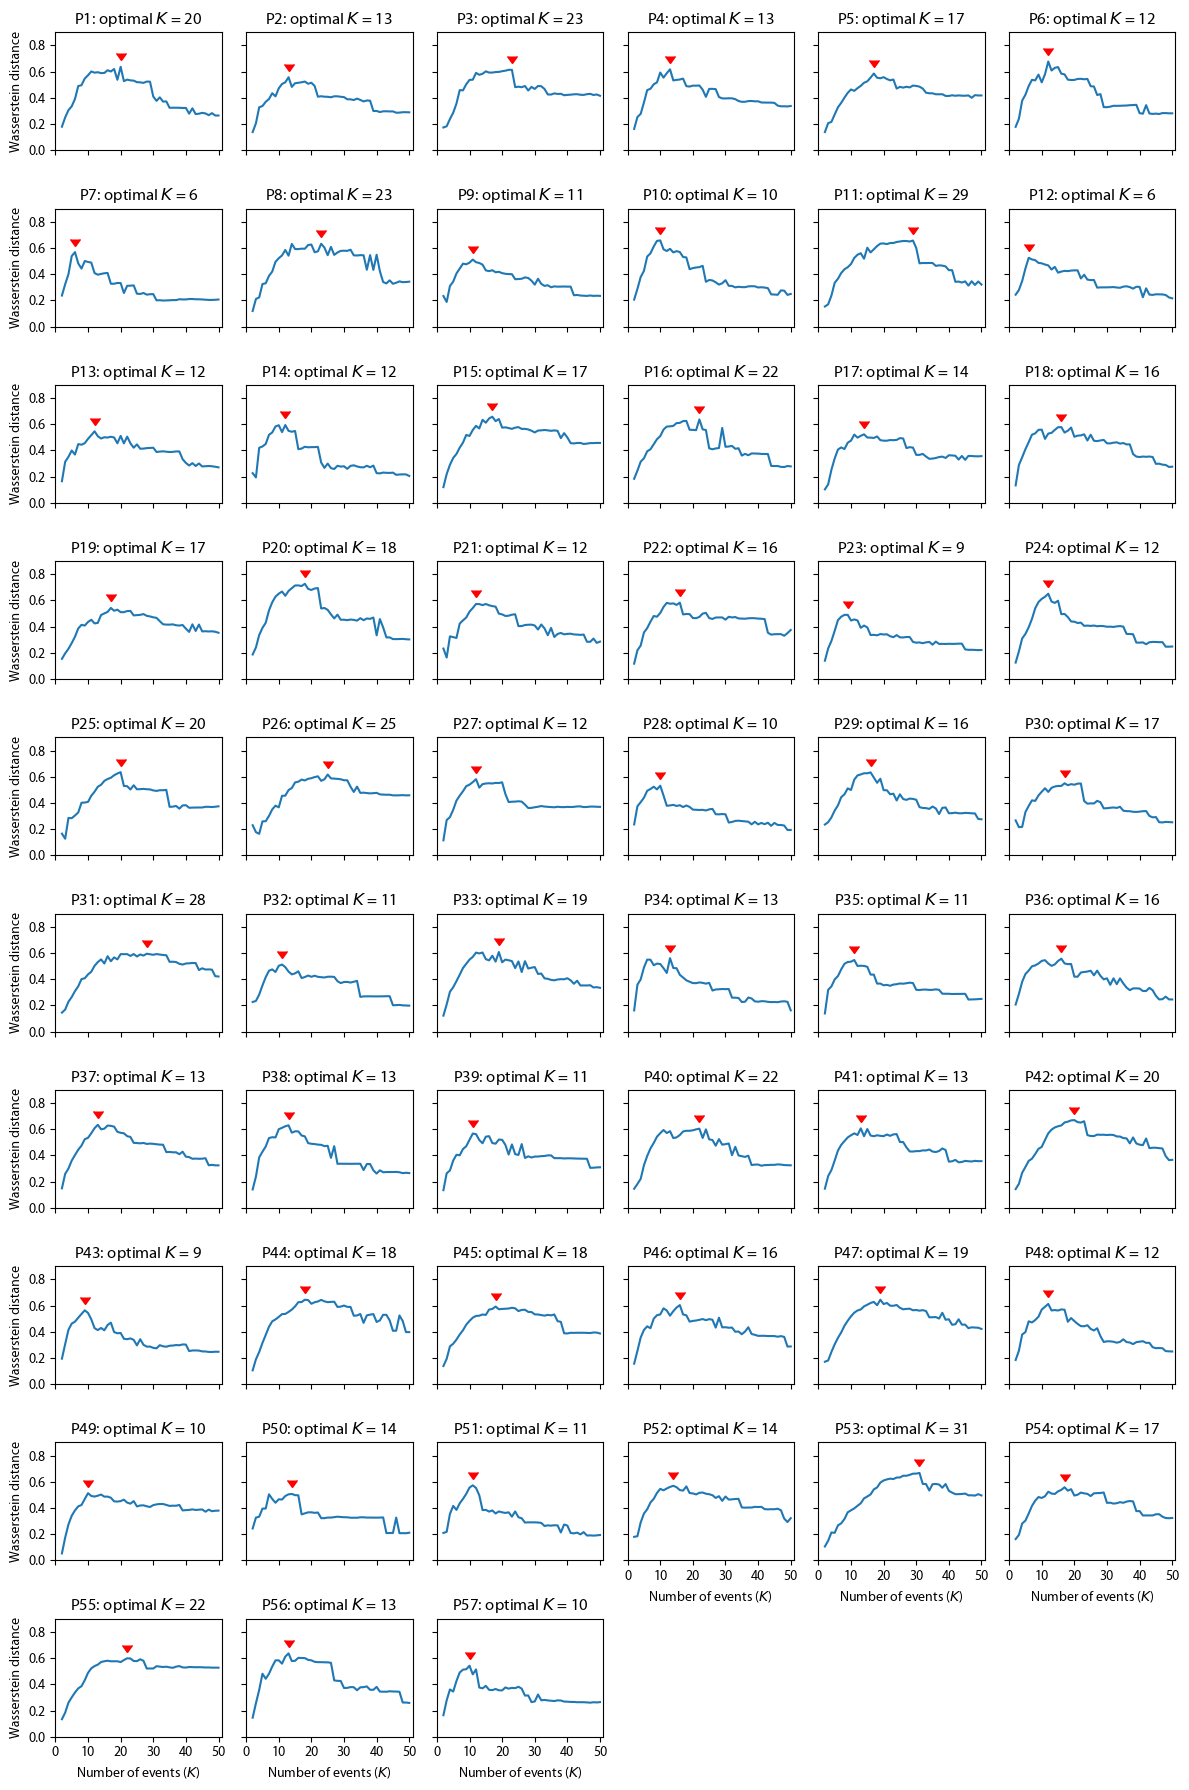

In [10]:
N_COLS = 6
for rectype in ('atlep1', 'delayed'):
    fig, axarr = plt.subplots(nrows=int(len(participants) / N_COLS) + 1, 
                              ncols=N_COLS, 
                              figsize=(12, 18))

    for i, (p, ax) in enumerate(zip_longest(participants, axarr.ravel())):
        if p is None:
            ax.axis('off')
            continue

        best_k = N_EVENTS_RANGE[p.eventseg_kvals[rectype].argmax()]
        sns.lineplot(x=N_EVENTS_RANGE, y=p.eventseg_kvals[rectype], ax=ax)
        ax.plot(best_k, p.eventseg_kvals[rectype].max() + 0.05, c='r', marker=7, markersize=7)
        
        ax.set_title(f'P{p.sub_n}: optimal $K$ = {best_k}')
        ax.set_xlim(0, 51)
        ax.set_xticks(list(range(0, 51, 10)))
        ax.set_ylim(0, 0.9)
        ax.set_yticks(np.arange(0, 1, 0.2))
        

        if i >= len(participants) - N_COLS:
            ax.set_xlabel('Number of events ($K$)')
        else:
            ax.set_xticklabels([])

        if not i % N_COLS:
            ax.set_ylabel('Wasserstein distance')
        else:
            ax.set_yticklabels([])

    plt.tight_layout()
#     plt.savefig(FIG_DIR.joinpath(f'k-optimization-{rectype}-recall.pdf'), 
#                 bbox_inches='tight')
    plt.show()

## Create & save average recall event sequence

In [11]:
for rectype in ('atlep1', 'delayed'):
    matched_rec_events = [[] for _ in atlep1.events]
    for p in participants:
        rec_events = p.events[rectype]
        ep_rec_corrmat = 1 - cdist(atlep1.events, rec_events, metric='correlation')
        event_matches = ep_rec_corrmat.argmax(axis=0)
        for rec_event_ix, ep_event_ix in enumerate(event_matches):
            matched_rec_events[ep_event_ix].append(rec_events[rec_event_ix])
            
    avg_rec_events = np.zeros(atlep1.events.shape)
    for ix, matched_events in enumerate(matched_rec_events):
        if len(matched_events) == 0:
            print(f'No recalls matching episode event {ix + 1}')
        else:
            avg_rec_events[ix] = np.mean(matched_events, axis=0)
    
    avg_participant.events[rectype] = avg_rec_events
#     np.save(avg_participant.data_dir.joinpath(f'{rectype}_recall_events.npy'), 
#             avg_participant.events[rectype])